# Opinosis 리뷰 텍스트 클러스터링

51개 오피니언 리뷰(Kindle, GPS, 호텔, 자동차, 넷북)를 벡터화하고 여러 클러스터링 알고리즘으로 비교합니다.

## 1. 데이터 로딩

In [1]:
import pandas as pd
import glob, os
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 700)

In [2]:
# 데이터 파일이 있는 디렉터리 경로 지정
path = r'C:\big21\01. semi_assignment\ml-data-analysis\data\topics'
# path로 지정한 디렉터리 밑에 있는 모든 .data 파일들의 파일명을 리스트로 취합
all_files = glob.glob(os.path.join(path, "*.data"))    
filename_list = []
opinion_text = []

In [3]:
# 개별 파일들의 파일명은 filename_list 리스트로 취합,
# 개별 파일들의 파일 내용은 DataFrame 로딩 후 다시 string으로 변환하여 opinion_text 리스트로 취합
for file_ in all_files:
    # 개별 파일을 읽어서 DataFrame으로 생성
    df = pd.read_table(file_,index_col=None, header=0,encoding='latin1')
   
    # 절대경로로 주어진 file 명을 가공. 만일 Linux에서 수행시에는 아래 \\를 / 변경.
    # 맨 마지막 .data 확장자도 제거
    filename_ = file_.split('\\')[-1]
    filename = filename_.split('.')[0]

    # 파일명 리스트와 파일 내용 리스트에 파일명과 파일 내용을 추가.
    filename_list.append(filename)
    opinion_text.append(df.to_string())


In [4]:
# 파일명 리스트와 파일 내용 리스트를  DataFrame으로 생성
document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})
document_df.head()

,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n0 but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n1 This functi..."
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n0 The second room was smaller, with a very inconvenient bathroom layout, but at least it was quieter and we were able to sleep .\n1 ..."
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n0 After you have paged tru a 500, page book one, page, at, a, time to get from Chapter 2 to Chapter 15, see how excited you are about a low battery and all the time it took to get there !\n1 ..."
3,battery-life_ipod_nano_8gb,short battery life I moved up from an 8gb .\n0 I love this ipod except for the battery life .\n1 ...
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n0 Not to mention that as of now..."


## 2. 전처리

소문자화 → 특수문자 제거 → 토큰화 → 불용어 제거 → **표제어 추출(lemmatization)** 순으로 정리합니다.
(표제어 추출을 새로 추가 — `battery`/`batteries`, `room`/`rooms`처럼 형태만 다른 단어를 하나로 통일)

In [5]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

def text_cleaning(text):
   
    # 소문자로 변환
    text = text.lower()
   
    # 영문자와 공백을 제외한 문자 제거
    text = re.sub(r'[^a-z\s]', ' ', text)
   
    # 여러 개의 공백을 하나로 변경
    text = re.sub(r'\s+', ' ', text)
   
    return text.strip()


# 원문 보관 (혹시모를 상황을 대비)
document_df['original_text'] = document_df['opinion_text']

#소문자 / 영문자/공백/여러개공백 처리
document_df['opinion_text'] = document_df['opinion_text'].apply(text_cleaning)

# 토크나이즈(각 단어들로 구분)
document_df['opinion_text'] = document_df['opinion_text'].apply(word_tokenize)

# 불용어 세팅
stop_words = set(stopwords.words('english'))

# 불용어 정리
document_df['opinion_text'] = document_df['opinion_text'].apply(
    lambda tokens: [
        word for word in tokens
        if word not in stop_words
    ]
)

# 표제어 추출(lemmatization) 적용 전 상태를 스냅샷으로 보관 -> 나중에 전/후 비교에 사용
document_df['opinion_text_no_lemma'] = document_df['opinion_text'].apply(lambda tokens: list(tokens))

# 표제어 추출 (lemmatization) - battery/batteries, room/rooms 같은 단어를 하나의 형태로 통일
lemmatizer = WordNetLemmatizer()
document_df['opinion_text'] = document_df['opinion_text'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

In [6]:
# 클렌징 및 토큰화 후, 최종 확인
document_df[['opinion_text']].head()

#단어 빈도수 체크에 대한 함수
for index, row in document_df.iterrows():
   
    # 클렌징된 텍스트 가져오기
    text = row['opinion_text']
   
    # 단어 빈도 계산
    word_counts = Counter(text)
   
    print(f"===== {row['filename']} =====")
    print(word_counts.most_common(30))
    print()

===== accuracy_garmin_nuvi_255W_gps =====
[('accurate', 48), ('accuracy', 13), ('gps', 12), ('direction', 11), ('map', 11), ('easy', 9), ('time', 7), ('road', 7), ('use', 7), ('used', 6), ('unit', 6), ('point', 6), ('street', 6), ('speed', 6), ('garmin', 5), ('one', 5), ('destination', 5), ('always', 5), ('good', 5), ('tell', 5), ('turn', 5), ('star', 4), ('nice', 4), ('pretty', 4), ('arrival', 4), ('w', 4), ('limit', 4), ('find', 3), ('route', 3), ('inaccurate', 3)]

===== bathroom_bestwestern_hotel_sfo =====
[('bathroom', 91), ('room', 48), ('clean', 23), ('nice', 12), ('small', 12), ('bed', 11), ('large', 10), ('sink', 10), ('also', 9), ('comfortable', 8), ('shower', 8), ('door', 7), ('good', 7), ('big', 6), ('well', 6), ('hotel', 6), ('plenty', 6), ('quite', 5), ('little', 5), ('adequate', 5), ('enough', 5), ('u', 5), ('space', 5), ('thing', 4), ('toilet', 4), ('basin', 4), ('one', 4), ('use', 4), ('toiletry', 4), ('size', 4)]

===== battery-life_amazon_kindle =====
[('battery', 97

## 3. TF-IDF 벡터화 & KMeans

In [7]:
# 토큰 리스트를 문자열로 합쳐서 TF-IDF에 사용
document_df['opinion_text_joined'] = document_df['opinion_text'].apply(lambda tokens: ' '.join(tokens))  # 토큰 -> 문자열

from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF 임포트

tfidf_vect = TfidfVectorizer(ngram_range=(1, 2), min_df=0.05, max_df=0.85)  # 벡터라이저 생성
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text_joined'])  # 벡터화 수행

feature_vect.shape  # 크기 확인

(51, 4462)

In [8]:
# KMeans로 그룹화 (클러스터 5개로 시작 - 나중에 조정)
from sklearn.cluster import KMeans  # KMeans 임포트

km_cluster = KMeans(n_clusters=5, max_iter=10000, random_state=0, n_init=10)  # 모델 생성
km_cluster.fit(feature_vect)  # 학습(군집화)

document_df['cluster_label'] = km_cluster.labels_  # 클러스터 번호 저장
document_df.sort_values('cluster_label')[['filename', 'cluster_label']]  # 정렬해서 확인

,filename,cluster_label
18,interior_toyota_camry_2007,0
17,interior_honda_accord_2008,0
3,battery-life_ipod_nano_8gb,1
2,battery-life_amazon_kindle,1
26,performance_netbook_1005ha,1
19,keyboard_netbook_1005ha,1
4,battery-life_netbook_1005ha,1
35,screen_ipod_nano_8gb,1
41,size_asus_netbook_1005ha,1
42,sound_ipod_nano_8gb,1


In [9]:
# 각 클러스터의 핵심 단어 + 소속 파일 확인 -> 여기서 클러스터에 "의미"를 붙임
def get_cluster_details(model, data, feature_names, n_clusters, top_n=10, label_col='cluster_label'):  # 상세 정리 함수
    order = model.cluster_centers_.argsort()[:, ::-1]  # 값 큰 순 인덱스
    details = {}  # 결과 딕셔너리
    for i in range(n_clusters):  # 클러스터별 반복
        top_idx = order[i, :top_n]  # 상위 단어 인덱스
        details[i] = {
            'top_features': [feature_names[j] for j in top_idx],  # 단어로 변환
            'filenames': data[data[label_col] == i]['filename'].tolist()  # 소속 파일
        }
    return details  # 반환


feature_names = tfidf_vect.get_feature_names_out()  # 전체 단어 목록
cluster_details = get_cluster_details(km_cluster, document_df, feature_names, 5)  # TF-IDF 기준 조회

for k, v in cluster_details.items():  # 클러스터별 출력
    print(f"=== Cluster {k} (TF-IDF) ===")  # 번호
    print("핵심 단어:", v['top_features'])  # 단어들
    print("파일:", v['filenames'])  # 파일들
    print()  # 빈 줄

=== Cluster 0 (TF-IDF) ===
핵심 단어: ['interior', 'exterior', 'interior exterior', 'design', 'seat', 'car', 'interior design', 'look', 'roomy', 'plastic']
파일: ['interior_honda_accord_2008', 'interior_toyota_camry_2007']

=== Cluster 1 (TF-IDF) ===
핵심 단어: ['battery', 'screen', 'battery life', 'life', 'keyboard', 'video', 'performance', 'size', 'sound', 'faster']
파일: ['battery-life_amazon_kindle', 'battery-life_ipod_nano_8gb', 'battery-life_netbook_1005ha', 'keyboard_netbook_1005ha', 'performance_netbook_1005ha', 'screen_ipod_nano_8gb', 'screen_netbook_1005ha', 'size_asus_netbook_1005ha', 'sound_ipod_nano_8gb', 'speed_windows7', 'video_ipod_nano_8gb']

=== Cluster 2 (TF-IDF) ===
핵심 단어: ['seat', 'mileage', 'gas', 'comfortable', 'gas mileage', 'transmission', 'performance', 'car', 'quality', 'comfort']
파일: ['comfort_honda_accord_2008', 'comfort_toyota_camry_2007', 'gas_mileage_toyota_camry_2007', 'mileage_honda_accord_2008', 'performance_honda_accord_2008', 'quality_toyota_camry_2007', 'seats

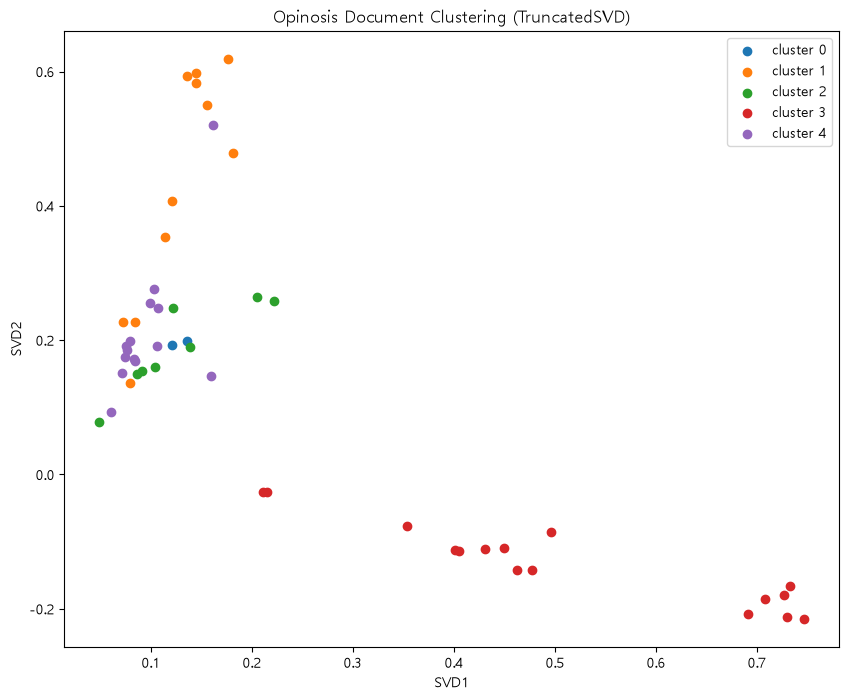

In [10]:
# TruncatedSVD 2차원 축소 + 클러스터별 산점도 (희소행렬에 직접 적용 가능 - TF-IDF엔 PCA보다 정석적인 방법)
from sklearn.decomposition import TruncatedSVD  # TruncatedSVD 임포트
import matplotlib.pyplot as plt  # 그래프 임포트
import matplotlib as mpl  # 폰트 설정용

mpl.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows 기본 한글 폰트)
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

svd_main = TruncatedSVD(n_components=2, random_state=0)  # 2차원 SVD
svd_result = svd_main.fit_transform(feature_vect)  # 축소 수행 (희소행렬 그대로 입력, toarray 불필요)

document_df['svd_x'] = svd_result[:, 0]  # x좌표 저장
document_df['svd_y'] = svd_result[:, 1]  # y좌표 저장

plt.figure(figsize=(10, 8))  # 그래프 크기
for label in sorted(document_df['cluster_label'].unique()):  # 클러스터별 반복
    sub = document_df[document_df['cluster_label'] == label]  # 해당 클러스터만 추출
    plt.scatter(sub['svd_x'], sub['svd_y'], label=f'cluster {label}')  # 산점도 그리기

plt.legend()  # 범례 표시
plt.title('Opinosis Document Clustering (TruncatedSVD)')  # 제목
plt.xlabel('SVD1')  # x축 라벨
plt.ylabel('SVD2')  # y축 라벨
plt.show()  # 출력

## 4. CountVectorizer 비교

In [11]:
# CountVectorizer로도 벡터화 (단순 등장 빈도 기반, TF-IDF와 비교용)
from sklearn.feature_extraction.text import CountVectorizer  # CountVectorizer 임포트

count_vect = CountVectorizer(ngram_range=(1, 2), min_df=0.05, max_df=0.85)  # 벡터라이저 생성
count_feature_vect = count_vect.fit_transform(document_df['opinion_text_joined'])  # 벡터화 수행

count_feature_vect.shape  # 크기 확인

(51, 4462)

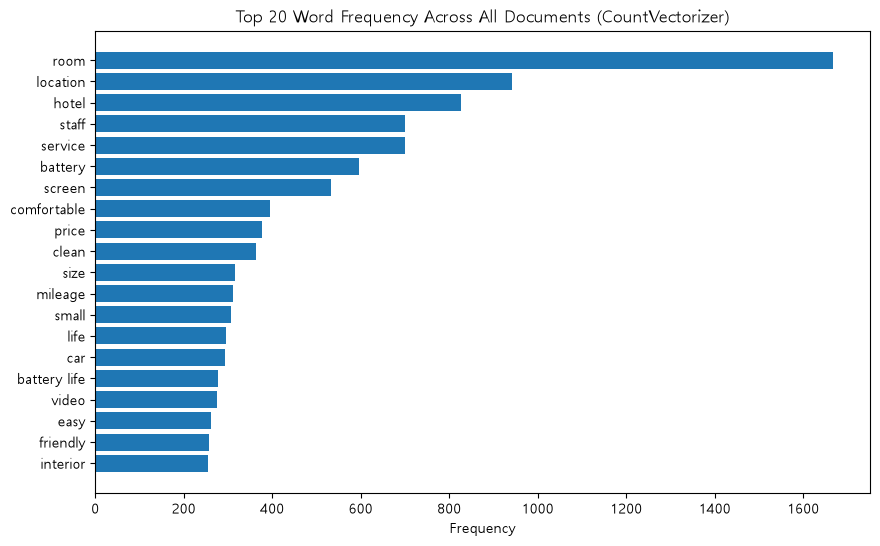

In [12]:
# 전체 코퍼스 단어 빈도 Top 20 (CountVectorizer 합산 기준)
import numpy as np  # numpy 임포트

count_sum = np.asarray(count_feature_vect.sum(axis=0)).ravel()  # 단어별 총 빈도
count_feature_names = count_vect.get_feature_names_out()  # 단어 목록

word_freq_df = (
    pd.DataFrame({'word': count_feature_names, 'count': count_sum})  # 표 생성
    .sort_values('count', ascending=False)  # 빈도순 정렬
    .head(20)  # 상위 20개
)

plt.figure(figsize=(10, 6))  # 그래프 크기
plt.barh(word_freq_df['word'][::-1], word_freq_df['count'][::-1])  # 가로 막대그래프
plt.title('Top 20 Word Frequency Across All Documents (CountVectorizer)')  # 제목
plt.xlabel('Frequency')  # x축 라벨
plt.show()  # 출력

In [13]:
# CountVectorizer 벡터로도 동일하게 KMeans 그룹화 (TF-IDF 결과와 비교용)
km_cluster_count = KMeans(n_clusters=5, max_iter=10000, random_state=0, n_init=10)  # 모델 생성
km_cluster_count.fit(count_feature_vect)  # 학습(군집화)

document_df['cluster_label_count'] = km_cluster_count.labels_  # 클러스터 번호 저장
document_df.sort_values('cluster_label_count')[['filename', 'cluster_label', 'cluster_label_count']]  # 비교 확인

,filename,cluster_label,cluster_label_count
0,accuracy_garmin_nuvi_255W_gps,4,0
1,bathroom_bestwestern_hotel_sfo,3,0
2,battery-life_amazon_kindle,1,0
3,battery-life_ipod_nano_8gb,1,0
5,buttons_amazon_kindle,4,0
6,comfort_honda_accord_2008,2,0
7,comfort_toyota_camry_2007,2,0
8,directions_garmin_nuvi_255W_gps,4,0
12,fonts_amazon_kindle,4,0
9,display_garmin_nuvi_255W_gps,4,0


In [14]:
# CountVectorizer 기반 클러스터의 핵심 단어 확인 (TF-IDF 버전과 비교)
cluster_details_count = get_cluster_details(
    km_cluster_count, document_df, count_feature_names, 5, label_col='cluster_label_count'  # count 기준 조회
)

for k, v in cluster_details_count.items():  # 클러스터별 출력
    print(f"=== Cluster {k} (CountVectorizer) ===")  # 번호
    print("핵심 단어:", v['top_features'])  # 단어들
    print("파일:", v['filenames'])  # 파일들
    print()  # 빈 줄

=== Cluster 0 (CountVectorizer) ===
핵심 단어: ['screen', 'mileage', 'price', 'video', 'comfortable', 'interior', 'car', 'battery', 'size', 'easy']
파일: ['accuracy_garmin_nuvi_255W_gps', 'bathroom_bestwestern_hotel_sfo', 'battery-life_amazon_kindle', 'battery-life_ipod_nano_8gb', 'buttons_amazon_kindle', 'comfort_honda_accord_2008', 'comfort_toyota_camry_2007', 'directions_garmin_nuvi_255W_gps', 'display_garmin_nuvi_255W_gps', 'eyesight-issues_amazon_kindle', 'features_windows7', 'fonts_amazon_kindle', 'food_holiday_inn_london', 'food_swissotel_chicago', 'free_bestwestern_hotel_sfo', 'gas_mileage_toyota_camry_2007', 'interior_honda_accord_2008', 'interior_toyota_camry_2007', 'keyboard_netbook_1005ha', 'mileage_honda_accord_2008', 'navigation_amazon_kindle', 'parking_bestwestern_hotel_sfo', 'performance_honda_accord_2008', 'performance_netbook_1005ha', 'price_amazon_kindle', 'price_holiday_inn_london', 'quality_toyota_camry_2007', 'satellite_garmin_nuvi_255W_gps', 'screen_garmin_nuvi_255W_gp

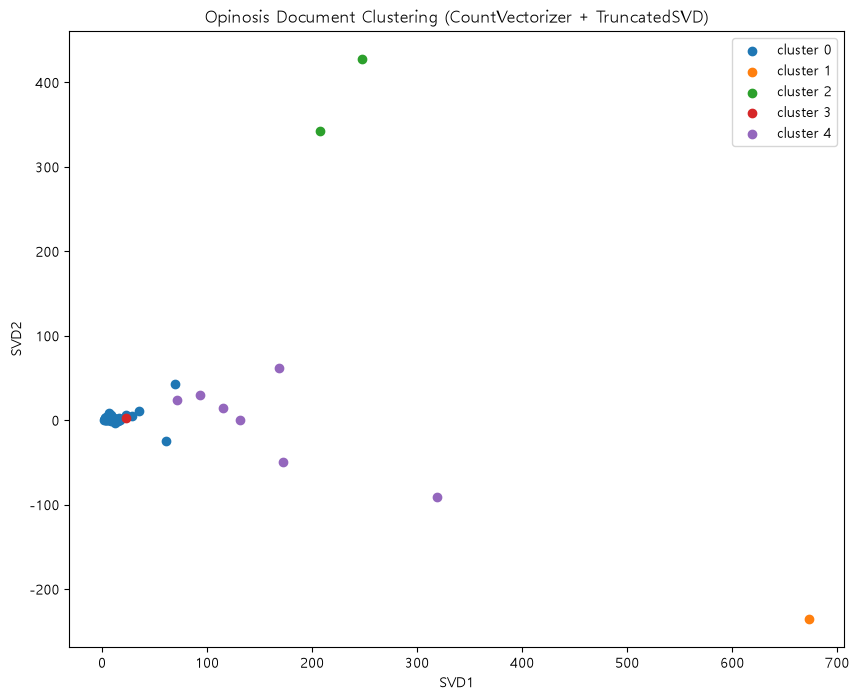

In [15]:
# CountVectorizer 결과도 TruncatedSVD 2차원 축소 + 클러스터별 산점도 (TF-IDF 산점도와 비교)
svd_count = TruncatedSVD(n_components=2, random_state=0)  # 2차원 SVD (count 벡터용)
svd_count_result = svd_count.fit_transform(count_feature_vect)  # 축소 수행 (희소행렬 그대로 입력)

document_df['svd_x_count'] = svd_count_result[:, 0]  # x좌표 저장
document_df['svd_y_count'] = svd_count_result[:, 1]  # y좌표 저장

plt.figure(figsize=(10, 8))  # 그래프 크기
for label in sorted(document_df['cluster_label_count'].unique()):  # 클러스터별 반복
    sub = document_df[document_df['cluster_label_count'] == label]  # 해당 클러스터만 추출
    plt.scatter(sub['svd_x_count'], sub['svd_y_count'], label=f'cluster {label}')  # 산점도 그리기

plt.legend()  # 범례 표시
plt.title('Opinosis Document Clustering (CountVectorizer + TruncatedSVD)')  # 제목
plt.xlabel('SVD1')  # x축 라벨
plt.ylabel('SVD2')  # y축 라벨
plt.show()  # 출력

In [16]:
# TF-IDF vs CountVectorizer 클러스터링 결과 비교
pd.crosstab(document_df['cluster_label'], document_df['cluster_label_count'],  # 교차표 생성
            rownames=['TF-IDF cluster'], colnames=['Count cluster'])  # 행/열 이름

Count cluster,0,1,2,3,4
TF-IDF cluster,,,,,
0,2,0,0,0,0
1,10,0,0,1,0
2,8,0,0,0,0
3,6,1,2,0,7
4,14,0,0,0,0


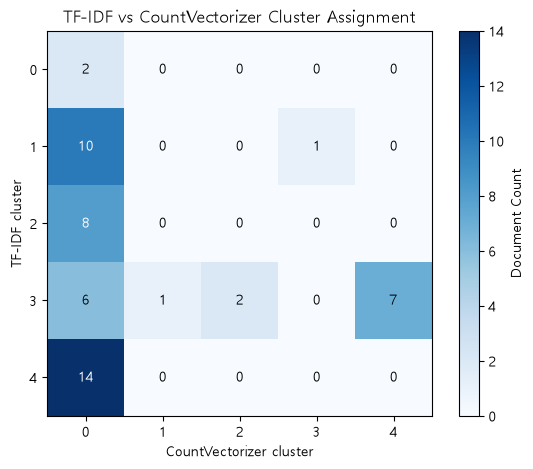

In [17]:
# 위 교차표를 히트맵으로 시각화 (숫자표보다 어디에 몰려있는지 한눈에 보임)
cross_tab = pd.crosstab(document_df['cluster_label'], document_df['cluster_label_count'],
                         rownames=['TF-IDF cluster'], colnames=['Count cluster'])  # 교차표 재생성

plt.figure(figsize=(7, 5))  # 그래프 크기
plt.imshow(cross_tab.values, cmap='Blues')  # 값이 클수록 진하게
plt.colorbar(label='Document Count')  # 컬러바
plt.xticks(range(len(cross_tab.columns)), cross_tab.columns)  # x축 눈금
plt.yticks(range(len(cross_tab.index)), cross_tab.index)  # y축 눈금
plt.xlabel('CountVectorizer cluster')  # x축 라벨
plt.ylabel('TF-IDF cluster')  # y축 라벨
plt.title('TF-IDF vs CountVectorizer Cluster Assignment')  # 제목

for i in range(cross_tab.shape[0]):  # 각 셀에 숫자 표시
    for j in range(cross_tab.shape[1]):
        val = cross_tab.values[i, j]
        plt.text(j, i, val, ha='center', va='center',
                 color='white' if val > cross_tab.values.max() / 2 else 'black')

plt.show()  # 출력

## 5. 실루엣 스코어 평가

In [18]:
# 실루엣 스코어로 클러스터링 품질 평가 (1에 가까울수록 잘 나뉜 것)
from sklearn.metrics import silhouette_score  # 실루엣 스코어 임포트

score_tfidf = silhouette_score(feature_vect, document_df['cluster_label'])  # TF-IDF 클러스터링 점수
score_count = silhouette_score(count_feature_vect, document_df['cluster_label_count'])  # Count 클러스터링 점수

print(f"TF-IDF 실루엣 스코어: {score_tfidf:.4f}")  # 결과 출력
print(f"CountVectorizer 실루엣 스코어: {score_count:.4f}")  # 결과 출력

TF-IDF 실루엣 스코어: 0.1047
CountVectorizer 실루엣 스코어: 0.3332


In [19]:
# 클러스터 개수(k)별 실루엣 스코어 비교 -> 적절한 클러스터 수 판단에 활용 (TF-IDF 기준)
silhouette_by_k = {}  # k별 점수를 저장할 딕셔너리

for k in list(range(2, 9)) + [51]:  # k를 2~8까지, 그리고 극단값 51(=문서 수, 문서당 클러스터 1개)도 확인
    km_k = KMeans(n_clusters=k, max_iter=10000, random_state=0, n_init=10)  # k개 클러스터 모델
    labels_k = km_k.fit_predict(feature_vect)  # 학습 + 라벨 예측
    try:
        score_k = silhouette_score(feature_vect, labels_k)  # 실루엣 스코어 계산
        silhouette_by_k[k] = score_k  # 점수 저장
        print(f"k={k}: silhouette={score_k:.4f}")  # 결과 출력
    except ValueError as e:
        print(f"k={k}: 실루엣 스코어 계산 불가 ({e})")  # 클러스터당 표본이 1개면 계산 불가

k=2: silhouette=0.0654
k=3: silhouette=0.0859
k=4: silhouette=0.0950
k=5: silhouette=0.1047
k=6: silhouette=0.1061


k=7: silhouette=0.0945
k=8: silhouette=0.1083


k=51: 실루엣 스코어 계산 불가 (Number of labels is 51. Valid values are 2 to n_samples - 1 (inclusive))


In [20]:
# 실루엣 스코어 계산 가능한 최대 클러스터 수(=문서 수 - 1)로 클러스터링
n_docs = feature_vect.shape[0]  # 전체 문서 수 (51)
max_k = n_docs - 1  # 실루엣 계산 가능한 최대 클러스터 수 (50)

km_max = KMeans(n_clusters=max_k, max_iter=10000, random_state=0, n_init=10)  # 최대 클러스터 모델
labels_max = km_max.fit_predict(feature_vect)  # 학습 + 라벨 예측
score_max = silhouette_score(feature_vect, labels_max)  # 실루엣 스코어 계산
silhouette_by_k[max_k] = score_max  # 점수 저장 (best k 탐색에 포함)

print(f"최대 클러스터 수: {max_k}")  # 결과 출력
print(f"실루엣 스코어: {score_max:.4f}")  # 결과 출력

document_df['cluster_label_max'] = labels_max  # 결과 저장
document_df.sort_values('cluster_label_max')[['filename', 'cluster_label_max']]  # 확인 (같은 번호끼리 묶인 문서 쌍이 가장 유사한 문서)

최대 클러스터 수: 50
실루엣 스코어: 0.0306


,filename,cluster_label_max
27,price_amazon_kindle,0
31,rooms_swissotel_chicago,1
41,size_asus_netbook_1005ha,2
25,performance_honda_accord_2008,3
0,accuracy_garmin_nuvi_255W_gps,4
6,comfort_honda_accord_2008,5
13,food_holiday_inn_london,6
34,screen_garmin_nuvi_255W_gps,7
38,service_bestwestern_hotel_sfo,8
3,battery-life_ipod_nano_8gb,9


In [21]:
# 지금까지 테스트한 k들 중 실루엣 스코어가 가장 높은 클러스터 수 찾기
best_k = max(silhouette_by_k, key=silhouette_by_k.get)  # 점수가 가장 높은 k

print(f"실루엣 스코어 최고점: k={best_k} (score={silhouette_by_k[best_k]:.4f})")  # 결과 출력
print(silhouette_by_k)  # 전체 k별 점수 확인

실루엣 스코어 최고점: k=8 (score=0.1083)
{2: 0.06540340721171337, 3: 0.08592110331995993, 4: 0.09500365495062914, 5: 0.10472689302538579, 6: 0.10605909782770716, 7: 0.09452687929202473, 8: 0.10832664120296287, 50: 0.03059309570318668}


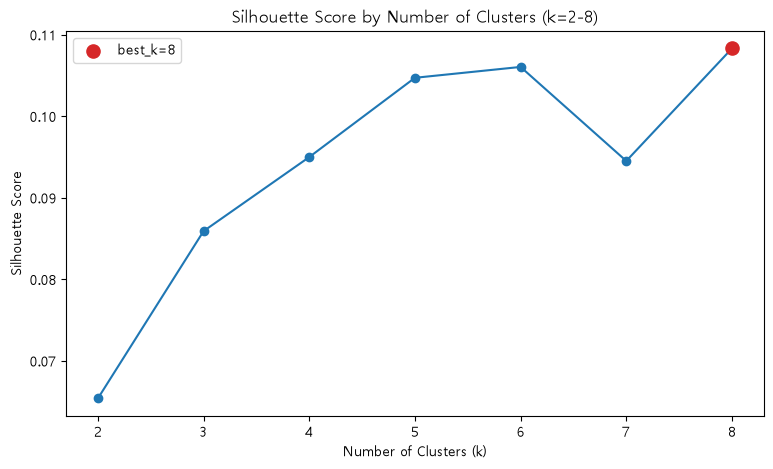

In [22]:
# k=2~8 실루엣 스코어를 그래프로 시각화 (best_k 지점 강조)
ks_plot = [k for k in silhouette_by_k if k <= 8]  # 50은 스케일이 깨져서 2~8만 표시
scores_plot = [silhouette_by_k[k] for k in ks_plot]  # 해당 점수

plt.figure(figsize=(9, 5))  # 그래프 크기
plt.plot(ks_plot, scores_plot, marker='o', color='tab:blue')  # k별 점수 라인
plt.scatter([best_k], [silhouette_by_k[best_k]], color='tab:red', zorder=5, s=90, label=f'best_k={best_k}')  # 최고점 강조
plt.xlabel('Number of Clusters (k)')  # x축 라벨
plt.ylabel('Silhouette Score')  # y축 라벨
plt.title('Silhouette Score by Number of Clusters (k=2-8)')  # 제목
plt.legend()  # 범례
plt.show()  # 출력

## 6. 5개 알고리즘 비교

In [23]:
# 5개 클러스터링 알고리즘 비교 준비: KMeans / 계층적(Agglomerative) / GMM / DBSCAN / MeanShift
from sklearn.cluster import DBSCAN, AgglomerativeClustering, MeanShift, estimate_bandwidth  # 추가 알고리즘 임포트
from sklearn.mixture import GaussianMixture  # GMM 임포트

X_dense = feature_vect.toarray()  # DBSCAN/GMM/MeanShift는 밀집 배열 입력 필요

In [24]:
# [1] KMeans - best_k로 재학습 (앞 섹션의 n_clusters=5 모델과는 별개 실행. 5개 알고리즘을 동일 조건에서 비교하기 위함)
km_compare = KMeans(n_clusters=best_k, max_iter=10000, random_state=0, n_init=10)  # 모델 생성
labels_kmeans = km_compare.fit_predict(feature_vect)  # 학습 + 라벨 예측

In [25]:
# [2] 계층적 클러스터링 (Agglomerative, 병합 기반)
agg = AgglomerativeClustering(n_clusters=best_k)  # 모델 생성
labels_agg = agg.fit_predict(X_dense)  # 학습 + 라벨 예측

In [26]:
# [3] GMM (가우시안 혼합모델, 확률 기반 소프트 군집화)
gmm = GaussianMixture(n_components=best_k, random_state=0)  # 모델 생성
labels_gmm = gmm.fit_predict(X_dense)  # 학습 + 라벨 예측

In [27]:
# [4] DBSCAN (밀도 기반, 클러스터 수 자동 결정 / -1은 노이즈)
dbscan = DBSCAN(eps=0.7, min_samples=2, metric='cosine')  # 코사인 거리 기준 (TF-IDF에 적합)
labels_dbscan = dbscan.fit_predict(X_dense)  # 학습 + 라벨 예측

In [28]:
# DBSCAN이 "노이즈(-1)"로 분류한 파일이 실제로 어떤 것들인지 확인
noise_files = document_df.loc[labels_dbscan == -1, 'filename']  # 노이즈로 분류된 행만 추출
print(f"노이즈로 분류된 파일 수: {len(noise_files)} / {len(document_df)}")  # 개수 확인
noise_files.tolist()  # 목록 출력

노이즈로 분류된 파일 수: 10 / 51


['features_windows7',
 'free_bestwestern_hotel_sfo',
 'parking_bestwestern_hotel_sfo',
 'quality_toyota_camry_2007',
 'satellite_garmin_nuvi_255W_gps',
 'sound_ipod_nano_8gb',
 'speed_windows7',
 'transmission_toyota_camry_2007',
 'updates_garmin_nuvi_255W_gps',
 'voice_garmin_nuvi_255W_gps']

In [29]:
# [5] Mean Shift (밀도 최고점 탐색, bandwidth 자동 추정)
bandwidth = estimate_bandwidth(X_dense, quantile=0.2, random_state=0)  # bandwidth 추정
mean_shift = MeanShift(bandwidth=bandwidth)  # 모델 생성
labels_meanshift = mean_shift.fit_predict(X_dense)  # 학습 + 라벨 예측

In [30]:
# 5개 알고리즘이 각각 클러스터를 몇 개로 찾았는지 확인
print("클러스터 수 - KMeans:", len(set(labels_kmeans)))  # 확인
print("클러스터 수 - Agglomerative:", len(set(labels_agg)))  # 확인
print("클러스터 수 - GMM:", len(set(labels_gmm)))  # 확인
print("클러스터 수 - DBSCAN:", len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0), "(노이즈 제외)")  # 확인
print("클러스터 수 - MeanShift:", len(set(labels_meanshift)))  # 확인

클러스터 수 - KMeans: 8
클러스터 수 - Agglomerative: 8
클러스터 수 - GMM: 8
클러스터 수 - DBSCAN: 9 (노이즈 제외)
클러스터 수 - MeanShift: 1


In [31]:
# 알고리즘별 실루엣 스코어 비교표 (DBSCAN 노이즈, 클러스터 1개인 경우는 계산 불가 처리)
def safe_silhouette(X, labels):  # 안전하게 실루엣 계산하는 함수
    labels = np.asarray(labels)  # 배열로 변환
    mask = labels != -1  # 노이즈(-1) 제외 마스크
    valid_labels = labels[mask]  # 노이즈 제외한 라벨
    if len(set(valid_labels)) < 2:  # 유효 클러스터가 1개 이하면
        return None  # 계산 불가
    return silhouette_score(X[mask], valid_labels)  # 실루엣 스코어 반환


results = []  # 비교 결과 리스트
for name, labels in [
    ('KMeans', labels_kmeans),
    ('Agglomerative', labels_agg),
    ('GMM', labels_gmm),
    ('DBSCAN', labels_dbscan),
    ('MeanShift', labels_meanshift),
]:  # 알고리즘별 반복
    n_found = len(set(labels)) - (1 if -1 in labels else 0)  # 노이즈 제외 클러스터 수
    n_noise = int((np.asarray(labels) == -1).sum())  # 노이즈 개수 (DBSCAN만 해당)
    score = safe_silhouette(feature_vect, labels)  # 실루엣 스코어 계산
    results.append({'algorithm': name, 'n_clusters': n_found, 'n_noise': n_noise, 'silhouette': score})  # 결과 저장

comparison_df = pd.DataFrame(results)  # 비교표 생성
comparison_df

,algorithm,n_clusters,n_noise,silhouette
0,KMeans,8,0,0.108327
1,Agglomerative,8,0,0.151799
2,GMM,8,0,0.083828
3,DBSCAN,9,10,0.191118
4,MeanShift,1,0,NaN


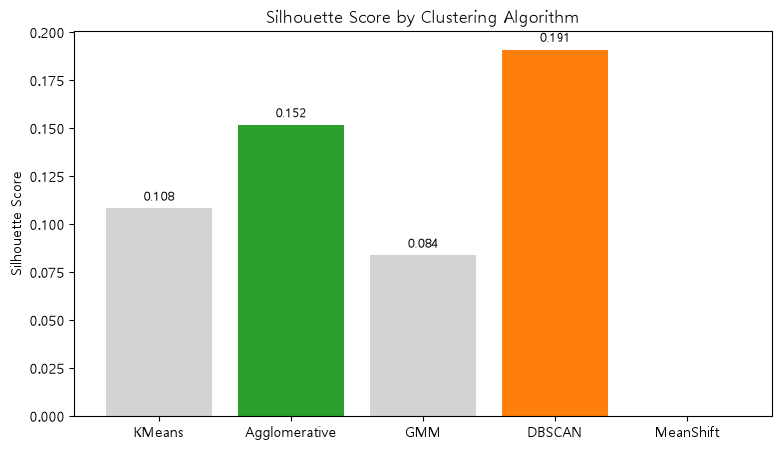

In [32]:
# 알고리즘별 실루엣 스코어를 막대그래프로 비교 (초록=최종 채택, 주황=점수는 높지만 노이즈 있어 제외)
color_map = {'Agglomerative': 'tab:green', 'DBSCAN': 'tab:orange'}  # 색상 매핑
colors = [color_map.get(name, 'lightgray') for name in comparison_df['algorithm']]  # 알고리즘별 색상

plt.figure(figsize=(9, 5))  # 그래프 크기
bars = plt.bar(comparison_df['algorithm'], comparison_df['silhouette'].fillna(0), color=colors)  # 막대그래프 (NaN은 0으로)
plt.ylabel('Silhouette Score')  # y축 라벨
plt.title('Silhouette Score by Clustering Algorithm')  # 제목

for i, row in comparison_df.iterrows():  # 막대 위에 값 표시
    label = f"{row['silhouette']:.3f}" if pd.notna(row['silhouette']) else 'N/A'  # NaN은 N/A로 표시
    plt.text(i, (row['silhouette'] or 0) + 0.004, label, ha='center', fontsize=9)

plt.show()  # 출력

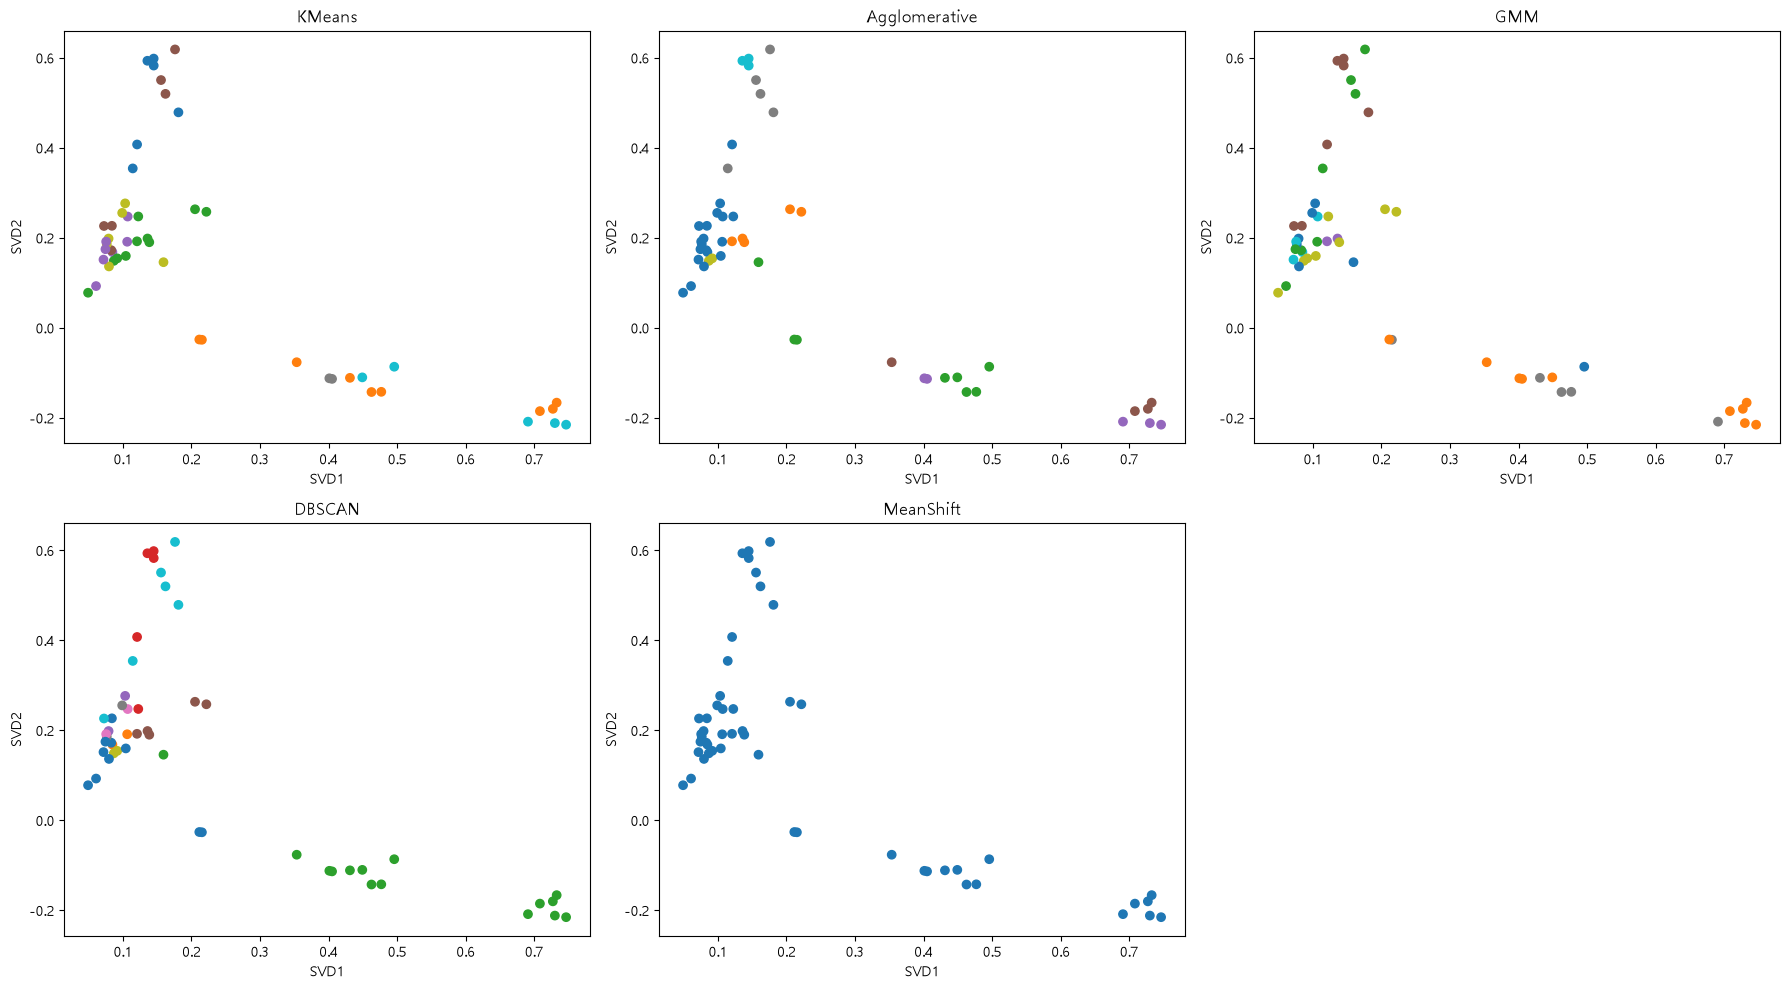

In [33]:
# 알고리즘별 클러스터링 결과를 동일한 TruncatedSVD 2차원 공간에서 나란히 시각화
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # 2행 3열 subplot
axes = axes.ravel()  # 1차원으로 평탄화

algo_labels = {
    'KMeans': labels_kmeans,
    'Agglomerative': labels_agg,
    'GMM': labels_gmm,
    'DBSCAN': labels_dbscan,
    'MeanShift': labels_meanshift,
}  # 알고리즘별 라벨 모음

for ax, (name, labels) in zip(axes, algo_labels.items()):  # 알고리즘별 반복
    ax.scatter(svd_result[:, 0], svd_result[:, 1], c=labels, cmap='tab10')  # 라벨별 색으로 산점도
    ax.set_title(name)  # 서브플롯 제목
    ax.set_xlabel('SVD1')  # x축 라벨
    ax.set_ylabel('SVD2')  # y축 라벨

axes[-1].axis('off')  # 알고리즘 5개, 칸 6개라 마지막 빈 칸은 숨김

plt.tight_layout()  # 레이아웃 정리
plt.show()  # 출력

## 7. 결론

In [34]:
# ===== 모델별 장단점 정리 =====

# [KMeans]
# 장점: 빠르고 구현이 간단함, 대용량 데이터에도 잘 확장됨
# 단점: 클러스터 수(k)를 미리 정해야 함 / 클러스터가 원형(구형)이라고 가정해서 고차원 희소 데이터엔 안 맞을 수 있음 / 랜덤 초기화라 매번 결과가 조금씩 달라질 수 있음(random_state로 고정 가능)

# [Agglomerative - 계층적 클러스터링]
# 장점: 클러스터 모양에 대한 가정이 없음 / 랜덤성이 전혀 없어 완전히 결정론적(재현성 좋음) / 덴드로그램으로 계층 구조도 확인 가능
# 단점: 클러스터 수(k)를 미리 정해야 함 / 데이터가 많아지면 계산량이 급격히 늘어남(O(n^2~n^3))

# [GMM - 가우시안 혼합모델]
# 장점: 각 문서가 여러 클러스터에 속할 확률까지 제공(소프트 군집화) / BIC·AIC로 클러스터 수를 어느 정도 비교/선택 가능
# 단점: 클러스터 수(n_components)를 미리 정해야 함 / 가우시안 분포를 가정해서 TF-IDF처럼 분포가 안 맞는 데이터엔 성능이 떨어질 수 있음

# [DBSCAN]
# 장점: 클러스터 수를 미리 안 정해도 됨(자동 결정) / 이상치(노이즈)를 자동으로 걸러줌 / 비정형 모양의 클러스터도 찾음
# 단점: eps·min_samples 값에 결과가 매우 민감함 / 밀도가 서로 다른 클러스터가 섞여 있으면 잘 못 찾음 / 일부 문서가 노이즈로 버려질 수 있음(이번 데이터는 약 20%)

# [MeanShift]
# 장점: 클러스터 수를 미리 안 정해도 됨(자동 결정) / bandwidth만 맞으면 밀도 기반으로 자연스럽게 군집화
# 단점: 고차원 희소 데이터(TF-IDF 등)에 매우 취약 - 이번 데이터에서도 전부 한 덩어리로 뭉쳐버림 / 계산 비용이 커서 대용량엔 부적합

# ===== 이번 데이터 결론 =====
# 51개 문서를 전부(빠짐없이) 분류해야 하므로, 노이즈 없이 전량 분류하는 알고리즘(KMeans/Agglomerative/GMM) 중에서 비교하는 게 맞음
# 그 중 Agglomerative가 실루엣 스코어가 가장 높아 이 데이터엔 최적 (comparison_df 참고)
# DBSCAN 점수가 더 높지만 문서의 20%를 노이즈로 버려서 "전체 분류"라는 목적엔 부적합
# MeanShift는 이 데이터 특성(고차원 희소)과 안 맞아 사용 부적합

In [35]:
# ===== 어떤 기준일 때 어떤 모델을 쓰면 좋은가 (일반화된 선택 가이드) =====
# 위 장단점을 "이럴 때는 이 모델" 식으로 뒤집어서 정리하면:

# [데이터 규모]
# - 데이터가 아주 크다(수만~수백만 건) -> KMeans (계산이 빠르고 확장성이 가장 좋음)
# - 데이터가 적다(수십~수백 건, 지금 이 노트북처럼) -> KMeans/Agglomerative가 안정적.
#   DBSCAN·MeanShift는 파라미터 하나 바꿀 때마다 결과가 크게 흔들릴 위험이 큼(10-1, 10-2 결과 참고)

# [클러스터 수를 아는지]
# - k(클러스터 수)를 미리 안다/정해도 상관없다 -> KMeans / Agglomerative / GMM
# - k를 전혀 모르고 자동으로 찾고 싶다 -> DBSCAN 또는 MeanShift
#   (단, 이번처럼 고차원 희소 데이터에서는 MeanShift는 거의 항상 실패함)

# [데이터의 차원/형태]
# - 고차원 희소 데이터(TF-IDF, 텍스트 임베딩 등) -> KMeans/Agglomerative/GMM 위주로 사용, MeanShift는 피할 것
# - 클러스터 모양이 원형(구형)이 아니라 길쭉하거나 불규칙할 것 같다 -> DBSCAN, Agglomerative(ward가 아닌 linkage),
#   MeanShift (모양에 대한 가정이 없음). 반대로 KMeans·GMM(공분산 제한 시)은 원형/타원형을 가정하므로 안 맞을 수 있음

# [분류 방식]
# - 데이터를 빠짐없이 전부 어딘가에 분류해야 한다 -> KMeans / Agglomerative / GMM
# - 이상치를 걸러내고 싶고, 애매한 데이터는 "노이즈"로 남겨도 된다 -> DBSCAN
# - 한 데이터가 여러 그룹에 애매하게 걸쳐있을 수 있다(소속을 딱 잘라 정하기 어렵다) -> GMM (확률 기반 소프트 군집화)

# [재현성 / 해석 가능성]
# - 몇 번을 돌려도 항상 같은 결과가 나와야 한다 -> Agglomerative (랜덤성 전혀 없음, 완전 결정론적)
#   KMeans도 random_state를 고정하면 재현 가능하지만, 초기화 방식 자체는 랜덤에 기반함
# - 클러스터 사이의 계층 구조(큰 그룹 -> 작은 그룹) 자체가 궁금하다 -> Agglomerative (덴드로그램으로 확인 가능)

# ===== 요약 =====
# "정답이 정해진 하나의 모델"은 없고, 데이터 크기/차원/모양, 그리고 "무엇을 더 중요하게 볼 것인가"에 따라 달라짐
# 이번 51개 문서 / 고차원 희소(TF-IDF) / k 몰라서 데이터 기반으로 찾아야 함 / 전부 분류 필요 / 재현성 중요
# -> 이 조건들을 종합하면 Agglomerative가 가장 잘 맞는 선택이었음

## 8. Lemmatization 적용 전후 비교 (Ablation)

전처리에서 표제어 추출을 껐을 때와 켰을 때 결과가 실제로 어떻게 달라지는지, 같은 노트북 안에서 직접 재현합니다.
(`opinion_text_no_lemma` = 표제어 추출 직전 스냅샷, `opinion_text` = 표제어 추출까지 끝난 최종본)

In [36]:
# lemmatization 적용 전(원본) 토큰으로도 동일하게 TF-IDF 벡터화
document_df['opinion_text_no_lemma_joined'] = document_df['opinion_text_no_lemma'].apply(lambda tokens: ' '.join(tokens))  # 토큰 -> 문자열

tfidf_vect_nolemma = TfidfVectorizer(ngram_range=(1, 2), min_df=0.05, max_df=0.85)  # 벡터라이저 생성 (동일 설정)
feature_vect_nolemma = tfidf_vect_nolemma.fit_transform(document_df['opinion_text_no_lemma_joined'])  # 벡터화 수행

feature_vect_nolemma.shape  # 크기 확인 (lemmatization 후보다 어휘 수가 더 많을 것)

(51, 4480)

In [37]:
# k=2~8에서 실루엣 스코어를 원본(no-lemma) 기준으로 재계산 -> lemmatization 적용 후(silhouette_by_k)와 나란히 비교
silhouette_by_k_nolemma = {}  # k별 점수를 저장할 딕셔너리 (원본 기준)

for k in range(2, 9):  # k를 2~8까지 확인
    km_k = KMeans(n_clusters=k, max_iter=10000, random_state=0, n_init=10)  # k개 클러스터 모델
    labels_k = km_k.fit_predict(feature_vect_nolemma)  # 학습 + 라벨 예측
    silhouette_by_k_nolemma[k] = silhouette_score(feature_vect_nolemma, labels_k)  # 실루엣 스코어 계산

best_k_nolemma = max(silhouette_by_k_nolemma, key=silhouette_by_k_nolemma.get)  # 원본 기준 최적 k

compare_k_df = pd.DataFrame({
    'k': list(silhouette_by_k_nolemma.keys()),
    'silhouette_before(원본)': list(silhouette_by_k_nolemma.values()),
    'silhouette_after(lemma)': [silhouette_by_k[k] for k in silhouette_by_k_nolemma.keys()],
})  # 전/후 비교표

print(f"적용 전 최적 k: {best_k_nolemma} (score={silhouette_by_k_nolemma[best_k_nolemma]:.4f})")  # 결과 출력
print(f"적용 후 최적 k: {best_k} (score={silhouette_by_k[best_k]:.4f})")  # 결과 출력
compare_k_df

적용 전 최적 k: 7 (score=0.1035)
적용 후 최적 k: 8 (score=0.1083)


,k,silhouette_before(원본),silhouette_after(lemma)
0,2,0.051955,0.065403
1,3,0.077947,0.085921
2,4,0.085799,0.095004
3,5,0.075425,0.104727
4,6,0.087194,0.106059
5,7,0.103539,0.094527
6,8,0.097802,0.108327


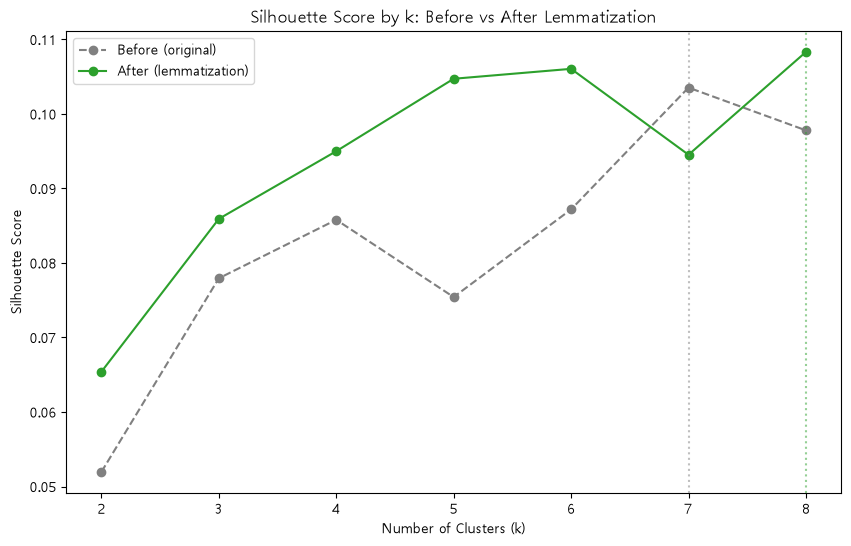

In [38]:
# k별 실루엣 스코어 전/후 비교 그래프
plt.figure(figsize=(10, 6))  # 그래프 크기
ks = list(silhouette_by_k_nolemma.keys())  # x축 (k값들)
plt.plot(ks, [silhouette_by_k_nolemma[k] for k in ks], marker='o', linestyle='--', color='gray', label='Before (original)')  # 점선
plt.plot(ks, [silhouette_by_k[k] for k in ks], marker='o', color='tab:green', label='After (lemmatization)')  # 실선
plt.axvline(best_k_nolemma, color='gray', linestyle=':', alpha=0.5)  # 적용 전 최적 k 표시
plt.axvline(best_k, color='tab:green', linestyle=':', alpha=0.5)  # 적용 후 최적 k 표시
plt.xlabel('Number of Clusters (k)')  # x축 라벨
plt.ylabel('Silhouette Score')  # y축 라벨
plt.title('Silhouette Score by k: Before vs After Lemmatization')  # 제목
plt.legend()  # 범례
plt.show()  # 출력

In [39]:
# 원본(no-lemma) 기준으로도 5개 알고리즘을 각자의 최적 k(best_k_nolemma)에서 다시 벤치마크
X_dense_nolemma = feature_vect_nolemma.toarray()  # 밀집 배열 변환

km_nl = KMeans(n_clusters=best_k_nolemma, max_iter=10000, random_state=0, n_init=10)  # KMeans
labels_kmeans_nl = km_nl.fit_predict(feature_vect_nolemma)

agg_nl = AgglomerativeClustering(n_clusters=best_k_nolemma)  # 계층적 클러스터링
labels_agg_nl = agg_nl.fit_predict(X_dense_nolemma)

gmm_nl = GaussianMixture(n_components=best_k_nolemma, random_state=0)  # GMM
labels_gmm_nl = gmm_nl.fit_predict(X_dense_nolemma)

dbscan_nl = DBSCAN(eps=0.7, min_samples=2, metric='cosine')  # DBSCAN (동일 파라미터)
labels_dbscan_nl = dbscan_nl.fit_predict(X_dense_nolemma)

bandwidth_nl = estimate_bandwidth(X_dense_nolemma, quantile=0.2, random_state=0)  # bandwidth 추정
mean_shift_nl = MeanShift(bandwidth=bandwidth_nl)  # MeanShift
labels_meanshift_nl = mean_shift_nl.fit_predict(X_dense_nolemma)

results_nl = []  # 결과 리스트
for name, labels in [
    ('KMeans', labels_kmeans_nl),
    ('Agglomerative', labels_agg_nl),
    ('GMM', labels_gmm_nl),
    ('DBSCAN', labels_dbscan_nl),
    ('MeanShift', labels_meanshift_nl),
]:  # 알고리즘별 반복
    n_found = len(set(labels)) - (1 if -1 in labels else 0)  # 노이즈 제외 클러스터 수
    n_noise = int((np.asarray(labels) == -1).sum())  # 노이즈 개수
    score = safe_silhouette(feature_vect_nolemma, labels)  # 실루엣 스코어
    results_nl.append({'algorithm': name, 'n_clusters': n_found, 'n_noise': n_noise, 'silhouette': score})

comparison_df_nolemma = pd.DataFrame(results_nl)  # 원본 기준 비교표
comparison_df_nolemma

,algorithm,n_clusters,n_noise,silhouette
0,KMeans,7,0,0.103539
1,Agglomerative,7,0,0.127095
2,GMM,7,0,0.089834
3,DBSCAN,10,10,0.189993
4,MeanShift,1,0,NaN


In [40]:
# 5개 알고리즘 실루엣 스코어를 전/후 나란히 정리 + 변화량(delta) 계산
bench_compare_df = comparison_df[['algorithm', 'silhouette']].rename(columns={'silhouette': 'silhouette_after(lemma)'})  # 적용 후
bench_compare_df['silhouette_before(원본)'] = comparison_df_nolemma.set_index('algorithm').loc[bench_compare_df['algorithm'], 'silhouette'].values  # 적용 전
bench_compare_df['delta'] = bench_compare_df['silhouette_after(lemma)'] - bench_compare_df['silhouette_before(원본)']  # 변화량

bench_compare_df

,algorithm,silhouette_after(lemma),silhouette_before(원본),delta
0,KMeans,0.108327,0.103539,0.004788
1,Agglomerative,0.151799,0.127095,0.024704
2,GMM,0.083828,0.089834,-0.006006
3,DBSCAN,0.191118,0.189993,0.001125
4,MeanShift,NaN,NaN,NaN


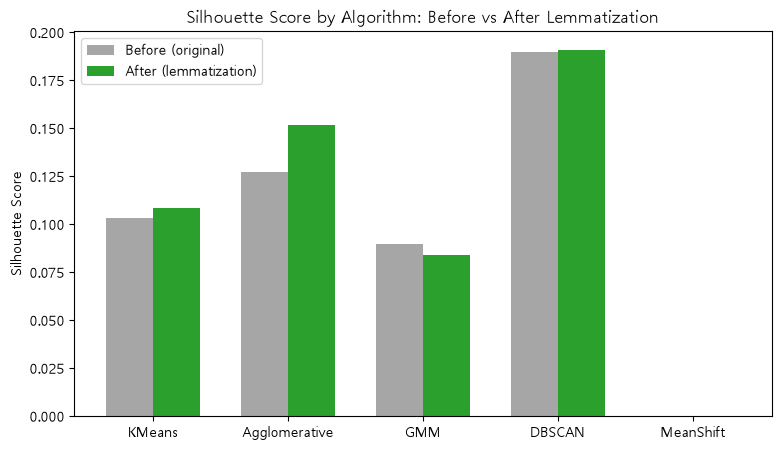

In [41]:
# 알고리즘별 lemmatization 적용 전/후 실루엣 스코어를 그룹 막대그래프로 비교
x = np.arange(len(bench_compare_df))  # x축 위치
width = 0.35  # 막대 폭

plt.figure(figsize=(9, 5))  # 그래프 크기
plt.bar(x - width / 2, bench_compare_df['silhouette_before(원본)'].fillna(0), width, label='Before (original)', color='gray', alpha=0.7)  # 적용 전
plt.bar(x + width / 2, bench_compare_df['silhouette_after(lemma)'].fillna(0), width, label='After (lemmatization)', color='tab:green')  # 적용 후
plt.xticks(x, bench_compare_df['algorithm'])  # x축 눈금
plt.ylabel('Silhouette Score')  # y축 라벨
plt.title('Silhouette Score by Algorithm: Before vs After Lemmatization')  # 제목
plt.legend()  # 범례
plt.show()  # 출력

## 9. TruncatedSVD vs PCA 비교 (차원 축소 방식)

지금까지 산점도는 전부 **TruncatedSVD**로 그렸습니다 (희소행렬에 직접 적용 가능해서 TF-IDF엔 PCA보다 정석적인 방법).
여기서는 비교 삼아 **PCA**로 바꿔서, 최종 채택 모델(Agglomerative, k=8) 기준으로 두 방식을 나란히 비교합니다.

In [42]:
# 비교 삼아 PCA로도 2차원 축소 (SVD와 달리 밀집행렬 필요 -> toarray)
from sklearn.decomposition import PCA  # PCA 임포트

pca_compare = PCA(n_components=2, random_state=0)  # 2차원 PCA
pca_compare_result = pca_compare.fit_transform(feature_vect.toarray())  # 축소 수행

document_df['pca_x'] = pca_compare_result[:, 0]  # x좌표 저장
document_df['pca_y'] = pca_compare_result[:, 1]  # y좌표 저장

document_df['cluster_label_best'] = labels_agg  # 최종 채택 모델(Agglomerative, best_k) 라벨 저장

print(f"TruncatedSVD 설명 분산 비율: {svd_main.explained_variance_ratio_.sum():.1%}")  # 지금까지 사용한 SVD가 원본 정보를 얼마나 보존했는지
print(f"PCA 설명 분산 비율: {pca_compare.explained_variance_ratio_.sum():.1%}")  # 비교용 PCA가 원본 정보를 얼마나 보존했는지

TruncatedSVD 설명 분산 비율: 10.9%
PCA 설명 분산 비율: 16.1%


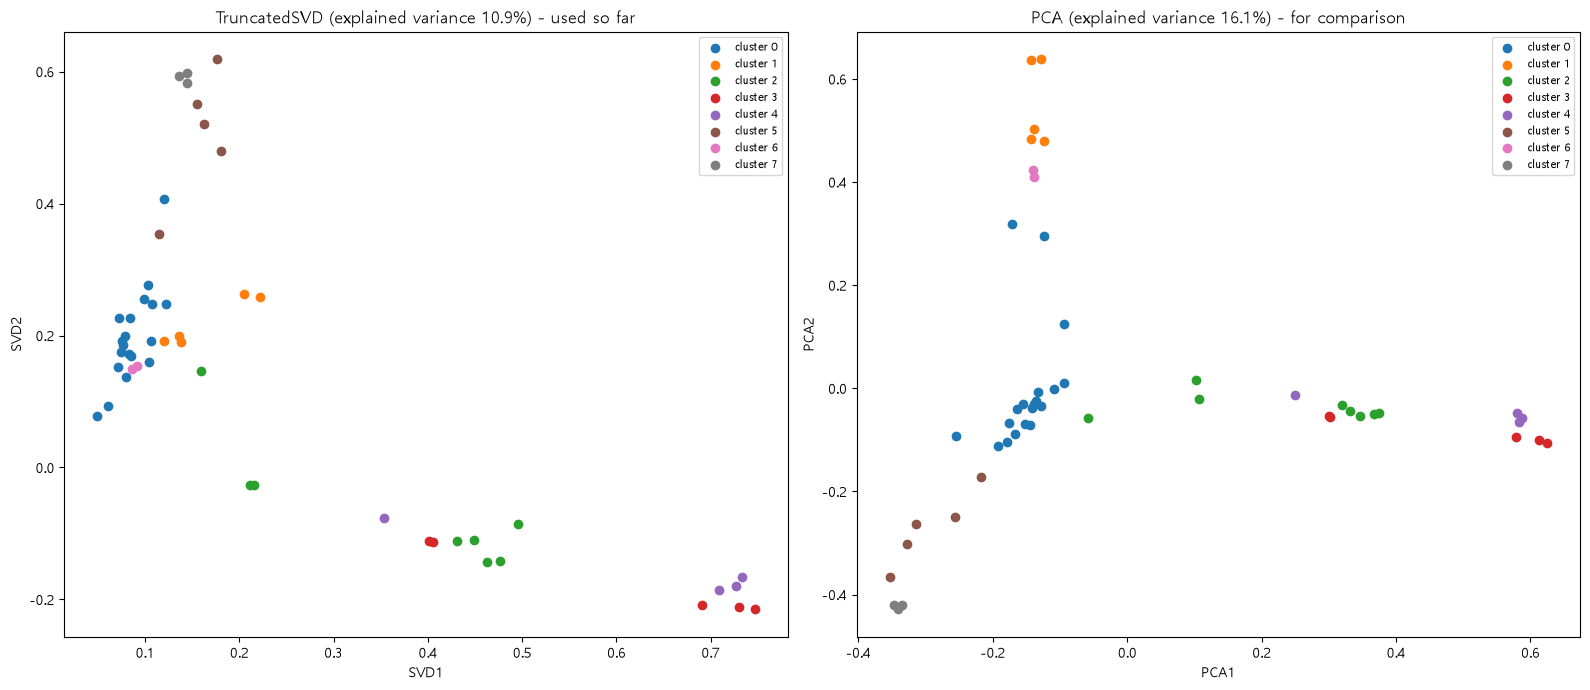

In [43]:
# 같은 클러스터 라벨(Agglomerative, best_k)로 TruncatedSVD(지금까지 사용) vs PCA(비교용) 산점도 나란히 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 7))  # 1행 2열 subplot

for label in sorted(document_df['cluster_label_best'].unique()):  # 클러스터별 반복
    sub = document_df[document_df['cluster_label_best'] == label]  # 해당 클러스터만 추출
    axes[0].scatter(sub['svd_x'], sub['svd_y'], label=f'cluster {label}')  # TruncatedSVD 산점도
axes[0].set_title(f'TruncatedSVD (explained variance {svd_main.explained_variance_ratio_.sum():.1%}) - used so far')  # 제목
axes[0].set_xlabel('SVD1')  # x축 라벨
axes[0].set_ylabel('SVD2')  # y축 라벨
axes[0].legend(fontsize=8)  # 범례

for label in sorted(document_df['cluster_label_best'].unique()):  # 클러스터별 반복
    sub = document_df[document_df['cluster_label_best'] == label]  # 해당 클러스터만 추출
    axes[1].scatter(sub['pca_x'], sub['pca_y'], label=f'cluster {label}')  # PCA 산점도
axes[1].set_title(f'PCA (explained variance {pca_compare.explained_variance_ratio_.sum():.1%}) - for comparison')  # 제목
axes[1].set_xlabel('PCA1')  # x축 라벨
axes[1].set_ylabel('PCA2')  # y축 라벨
axes[1].legend(fontsize=8)  # 범례

plt.tight_layout()  # 레이아웃 정리
plt.show()  # 출력

## 10. AI 도움 받은 곳(보고서 반영 X)

여기부터는 Claude(AI)의 도움을 받아 추가로 진행한 개선 실험입니다.

이 셀 이후의 부분은 보고서 작성을 할 때 반영하지 않도록 합니다.

- **10-1. Agglomerative linkage/metric 튜닝**: 최종 채택 모델의 세부 설정을 스캔해서 지금 쓰는 기본값(ward+euclidean)보다 나은 조합이 있는지 확인
- **10-2. 도메인 불용어 제거**: 여러 문서에 공통으로 등장해서 클러스터를 구분하는 데 도움이 안 되는 범용 단어를 추가로 제거하고, 실제로 효과가 있는지 검증

(문장 임베딩처럼 외부 사전학습 모델을 다운로드해야 하는 방법은 이번엔 제외했습니다.)

### 10-1. Agglomerative linkage / metric 튜닝

지금까지는 `AgglomerativeClustering`의 기본값(`linkage='ward'`, `metric='euclidean'`)만 사용했습니다.

- `linkage`: 두 클러스터를 병합할 때 "클러스터 사이의 거리"를 어떻게 정의할지 (ward=분산 최소화 / complete=최장 거리 / average=평균 거리 / single=최단 거리)
- `metric`: 애초에 두 문서 사이의 거리를 어떻게 잴지 (euclidean=직선 거리 / cosine=방향 유사도 / manhattan=격자 거리)

TF-IDF는 벡터의 **방향**(어떤 단어 비율로 이루어져 있는지)이 중요하고 **크기**(문서 길이)는 덜 중요한 데이터라, 이론적으로는 `cosine` 거리가 더 잘 맞는다고 알려져 있습니다. 실제로 그런지 조합을 전부 스캔해서 확인합니다.
(단, `ward`는 분산을 최소화하는 방식이라 수학적으로 `euclidean` 거리만 지원해서 다른 metric과는 조합이 안 됩니다.)

In [44]:
# linkage x metric 조합별 실루엣 스코어 스캔 (best_k 기준, feature_vect=lemmatization 적용된 TF-IDF)
linkages = ['ward', 'complete', 'average', 'single']  # 시도할 linkage 종류
metrics = ['euclidean', 'cosine', 'manhattan']  # 시도할 metric 종류

tuning_results = []  # 결과 리스트
for linkage in linkages:  # linkage별 반복
    for metric in metrics:  # metric별 반복
        if linkage == 'ward' and metric != 'euclidean':  # ward는 euclidean만 지원 -> 나머지 조합은 건너뜀
            continue
        model = AgglomerativeClustering(n_clusters=best_k, linkage=linkage, metric=metric)  # 모델 생성
        labels = model.fit_predict(X_dense)  # 학습 + 라벨 예측
        score = silhouette_score(feature_vect, labels)  # 실루엣 스코어 계산
        tuning_results.append({'linkage': linkage, 'metric': metric, 'silhouette': score})  # 결과 저장

tuning_df = pd.DataFrame(tuning_results).sort_values('silhouette', ascending=False).reset_index(drop=True)  # 점수 높은 순 정렬
tuning_df

,linkage,metric,silhouette
0,ward,euclidean,0.151799
1,average,cosine,0.097775
2,average,euclidean,0.097775
3,complete,euclidean,0.096209
4,complete,cosine,0.096209
5,complete,manhattan,0.076212
6,average,manhattan,0.046209
7,single,euclidean,0.034880
8,single,cosine,0.034880
9,single,manhattan,0.022424


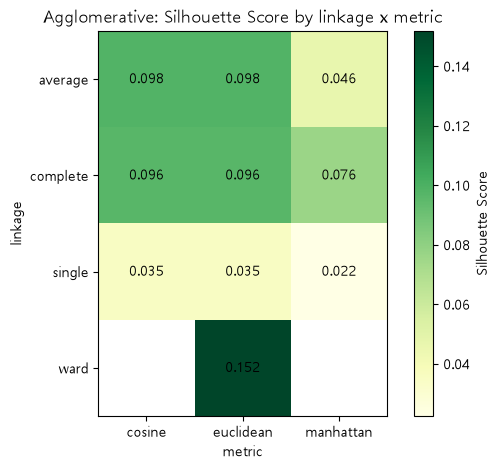

최고 조합: linkage=ward, metric=euclidean, silhouette=0.1518
기존 채택(ward+euclidean) 점수: 0.1518
변화량: +0.0000


In [45]:
# linkage x metric 조합을 히트맵으로 시각화 + 기존 채택 설정(ward+euclidean) 대비 변화 확인
heat = tuning_df.pivot(index='linkage', columns='metric', values='silhouette')  # linkage x metric 행렬로 변환

plt.figure(figsize=(7, 5))  # 그래프 크기
plt.imshow(heat.values, cmap='YlGn')  # 값이 클수록 진한 초록
plt.colorbar(label='Silhouette Score')  # 컬러바
plt.xticks(range(len(heat.columns)), heat.columns)  # x축 눈금
plt.yticks(range(len(heat.index)), heat.index)  # y축 눈금
plt.xlabel('metric')  # x축 라벨
plt.ylabel('linkage')  # y축 라벨
plt.title('Agglomerative: Silhouette Score by linkage x metric')  # 제목

for i in range(heat.shape[0]):  # 각 셀에 값 표시 (해당 조합이 없으면 NaN이라 건너뜀)
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        if not np.isnan(val):
            plt.text(j, i, f'{val:.3f}', ha='center', va='center')

plt.show()  # 출력

best_combo = tuning_df.iloc[0]  # 최고 점수 조합
current_score = bench_compare_df.loc[bench_compare_df['algorithm'] == 'Agglomerative', 'silhouette_after(lemma)'].values[0]  # 기존 채택(ward+euclidean) 점수

print(f"최고 조합: linkage={best_combo['linkage']}, metric={best_combo['metric']}, silhouette={best_combo['silhouette']:.4f}")  # 최고 조합 출력
print(f"기존 채택(ward+euclidean) 점수: {current_score:.4f}")  # 비교 기준 출력
print(f"변화량: {best_combo['silhouette'] - current_score:+.4f}")  # 변화량 출력

### 10-2. 도메인 불용어 제거

nltk 기본 불용어는 `the`, `is`, `and`처럼 문법적으로 의미 없는 단어만 제거합니다. 하지만 리뷰 텍스트에는 `thing`, `use`, `easy`, `problem`처럼 **문법적으로는 멀쩡한 단어지만 어떤 주제에도 치우치지 않고 아무 리뷰에나 등장하는 범용 단어**가 많습니다. 이런 단어는 어느 클러스터에나 골고루 섞여 있어서 클러스터를 구분하는 데 도움이 안 되고, 오히려 서로 다른 주제의 문서를 비슷해 보이게 만드는 노이즈로 작용합니다.

감이 아니라 **실제 데이터 기준**으로 고르기 위해, 단어별 문서빈도(=이 단어가 전체 51개 문서 중 몇 개에 등장하는지)를 계산합니다. 문서빈도가 높은데 실제로 특정 주제와 무관한 단어만 골라 불용어에 추가합니다.

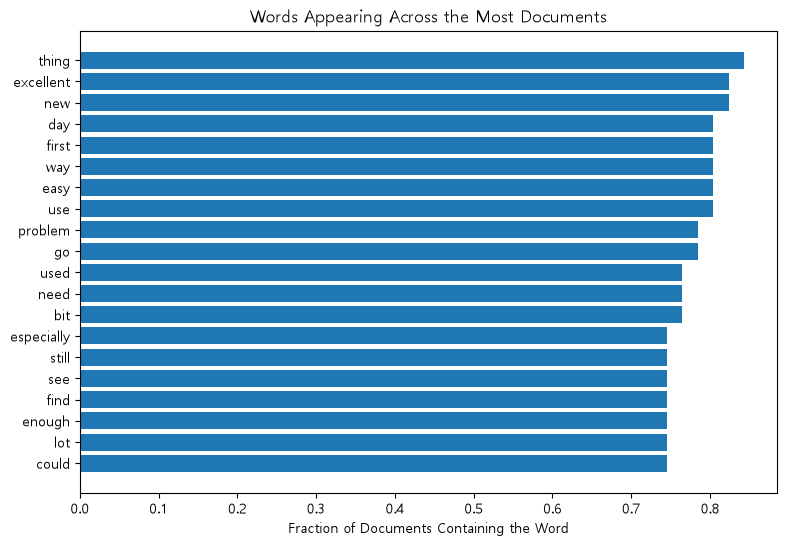

,word,doc_count,doc_ratio
2056,thing,43,0.843137
709,excellent,42,0.823529
1339,new,42,0.823529
524,day,41,0.803922
789,first,41,0.803922
2246,way,41,0.803922
637,easy,41,0.803922
2189,use,41,0.803922
1566,problem,40,0.784314
885,go,40,0.784314


In [46]:
# 단어별 문서빈도(document frequency) 계산 -> 여러 문서에 공통으로 등장하는 범용 단어 찾기
cv_df = CountVectorizer(ngram_range=(1, 1), min_df=0.05, max_df=0.85, binary=True)  # 등장 여부만 (1회 이상=1), 단일 단어만
X_df = cv_df.fit_transform(document_df['opinion_text_joined'])  # 이미 lemmatization까지 적용된 텍스트 사용

doc_freq = np.asarray(X_df.sum(axis=0)).ravel()  # 단어별 등장 문서 수
doc_freq_df = pd.DataFrame({
    'word': cv_df.get_feature_names_out(),
    'doc_count': doc_freq,
    'doc_ratio': doc_freq / len(document_df),  # 전체 문서 대비 비율
}).sort_values('doc_count', ascending=False)  # 문서빈도 높은 순 정렬

top20_freq = doc_freq_df.head(20)  # 상위 20개
plt.figure(figsize=(9, 6))  # 그래프 크기
plt.barh(top20_freq['word'][::-1], top20_freq['doc_ratio'][::-1])  # 가로 막대그래프
plt.xlabel('Fraction of Documents Containing the Word')  # x축 라벨
plt.title('Words Appearing Across the Most Documents')  # 제목
plt.show()  # 출력

doc_freq_df.head(20)

In [47]:
# 문서빈도 70% 이상인 단어 중, 실제로 주제와 무관한 범용 단어만 골라 도메인 불용어로 추가
# (car, feature는 문서빈도는 높지만 실제 주제(자동차/기능)와 관련이 있어서 제외)
domain_stopwords = set(doc_freq_df[doc_freq_df['doc_ratio'] >= 0.70]['word']) - {'car', 'feature'}  # 주제 관련 단어는 예외 처리
print(f"도메인 불용어 {len(domain_stopwords)}개:")  # 개수 출력
print(sorted(domain_stopwords))  # 목록 출력

document_df['opinion_text_domain'] = document_df['opinion_text'].apply(
    lambda tokens: [w for w in tokens if w not in domain_stopwords]
)  # 도메인 불용어까지 제거한 토큰
document_df['opinion_text_domain_joined'] = document_df['opinion_text_domain'].apply(lambda t: ' '.join(t))  # 문자열로 합침

tfidf_vect_domain = TfidfVectorizer(ngram_range=(1, 2), min_df=0.05, max_df=0.85)  # 벡터라이저 생성 (동일 설정)
feature_vect_domain = tfidf_vect_domain.fit_transform(document_df['opinion_text_domain_joined'])  # 벡터화 수행

feature_vect_domain.shape  # 크기 확인 (어휘 수가 줄었을 것)

도메인 불용어 30개:
['big', 'bit', 'could', 'day', 'easy', 'enough', 'especially', 'excellent', 'far', 'find', 'first', 'found', 'go', 'got', 'lot', 'many', 'need', 'new', 'problem', 'quite', 'right', 'see', 'still', 'take', 'thing', 'think', 'though', 'use', 'used', 'way']


(51, 4225)

In [48]:
# 도메인 불용어 제거 전(=lemmatization만 적용) vs 후, k별 실루엣 스코어 비교
silhouette_by_k_domain = {}  # k별 점수를 저장할 딕셔너리 (도메인 불용어 적용 기준)

for k in range(2, 9):  # k를 2~8까지 확인
    km_k = KMeans(n_clusters=k, max_iter=10000, random_state=0, n_init=10)  # k개 클러스터 모델
    labels_k = km_k.fit_predict(feature_vect_domain)  # 학습 + 라벨 예측
    silhouette_by_k_domain[k] = silhouette_score(feature_vect_domain, labels_k)  # 실루엣 스코어 계산

best_k_domain = max(silhouette_by_k_domain, key=silhouette_by_k_domain.get)  # 도메인 불용어 적용 기준 최적 k

compare_domain_df = pd.DataFrame({
    'k': list(silhouette_by_k_domain.keys()),
    'silhouette_lemma_only': [silhouette_by_k[k] for k in silhouette_by_k_domain],  # lemmatization만
    'silhouette_lemma_domain': list(silhouette_by_k_domain.values()),  # lemmatization + 도메인 불용어
})  # 비교표

print(f"lemmatization만 적용 시 최적 k: {best_k} (score={silhouette_by_k[best_k]:.4f})")  # 결과 출력
print(f"도메인 불용어까지 추가 시 최적 k: {best_k_domain} (score={silhouette_by_k_domain[best_k_domain]:.4f})")  # 결과 출력
compare_domain_df

lemmatization만 적용 시 최적 k: 8 (score=0.1083)
도메인 불용어까지 추가 시 최적 k: 8 (score=0.1094)


,k,silhouette_lemma_only,silhouette_lemma_domain
0,2,0.065403,0.059739
1,3,0.085921,0.085547
2,4,0.095004,0.095507
3,5,0.104727,0.105252
4,6,0.106059,0.107472
5,7,0.094527,0.096779
6,8,0.108327,0.109430


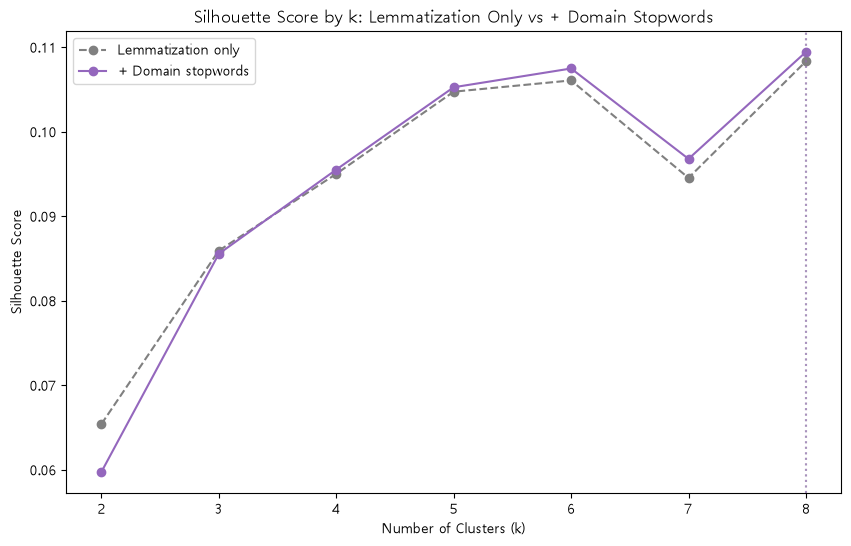

In [49]:
# k별 실루엣 스코어 비교 그래프 (lemmatization만 vs + 도메인 불용어)
plt.figure(figsize=(10, 6))  # 그래프 크기
ks = list(silhouette_by_k_domain.keys())  # x축 (k값들)
plt.plot(ks, [silhouette_by_k[k] for k in ks], marker='o', linestyle='--', color='gray', label='Lemmatization only')  # 점선
plt.plot(ks, [silhouette_by_k_domain[k] for k in ks], marker='o', color='tab:purple', label='+ Domain stopwords')  # 실선
plt.axvline(best_k, color='gray', linestyle=':', alpha=0.5)  # lemmatization만 적용 시 최적 k
plt.axvline(best_k_domain, color='tab:purple', linestyle=':', alpha=0.5)  # 도메인 불용어까지 적용 시 최적 k
plt.xlabel('Number of Clusters (k)')  # x축 라벨
plt.ylabel('Silhouette Score')  # y축 라벨
plt.title('Silhouette Score by k: Lemmatization Only vs + Domain Stopwords')  # 제목
plt.legend()  # 범례
plt.show()  # 출력

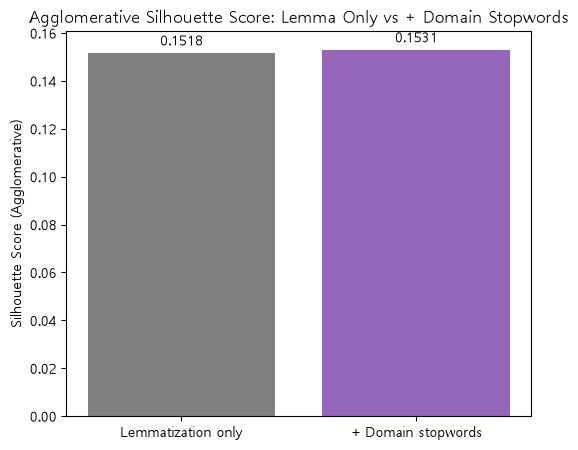

Agglomerative 실루엣 스코어 - lemmatization만: 0.1518
Agglomerative 실루엣 스코어 - +도메인 불용어: 0.1531
변화량: +0.0013


In [50]:
# 도메인 불용어까지 적용한 상태에서 Agglomerative(최종 채택 알고리즘)를 다시 벤치마크
X_dense_domain = feature_vect_domain.toarray()  # 밀집 배열 변환
agg_domain = AgglomerativeClustering(n_clusters=best_k_domain)  # 모델 생성
labels_agg_domain = agg_domain.fit_predict(X_dense_domain)  # 학습 + 라벨 예측
score_agg_domain = silhouette_score(feature_vect_domain, labels_agg_domain)  # 실루엣 스코어 계산

score_agg_lemma = bench_compare_df.loc[bench_compare_df['algorithm'] == 'Agglomerative', 'silhouette_after(lemma)'].values[0]  # 비교 기준

plt.figure(figsize=(6, 5))  # 그래프 크기
plt.bar(['Lemmatization only', '+ Domain stopwords'], [score_agg_lemma, score_agg_domain], color=['gray', 'tab:purple'])  # 막대그래프
plt.ylabel('Silhouette Score (Agglomerative)')  # y축 라벨
plt.title('Agglomerative Silhouette Score: Lemma Only vs + Domain Stopwords')  # 제목
for i, v in enumerate([score_agg_lemma, score_agg_domain]):  # 막대 위에 값 표시
    plt.text(i, v + 0.003, f'{v:.4f}', ha='center')
plt.show()  # 출력

print(f"Agglomerative 실루엣 스코어 - lemmatization만: {score_agg_lemma:.4f}")  # 결과 출력
print(f"Agglomerative 실루엣 스코어 - +도메인 불용어: {score_agg_domain:.4f}")  # 결과 출력
print(f"변화량: {score_agg_domain - score_agg_lemma:+.4f}")  # 변화량 출력

### 10-3. Agglomerative 덴드로그램 시각화

앞서 설명한 "51개 문서가 하나씩 합쳐져서 결국 1개로 뭉치는 과정" 전체를 나무 그림(덴드로그램)으로 직접 그려봅니다.

- **x축**: 문서(리프 노드) — 맨 처음엔 51개가 전부 따로따로였음
- **y축**: 병합 거리 — 두 그룹이 합쳐질 때 얼마나 멀리 떨어져 있었는지 (낮을수록 일찍/가깝게 합쳐짐)
- **점선(수평선)**: `best_k=8`개로 자르는 지점 — 이 선 아래에서 색으로 구분된 가지 하나하나가 지금 채택한 8개 클러스터에 해당

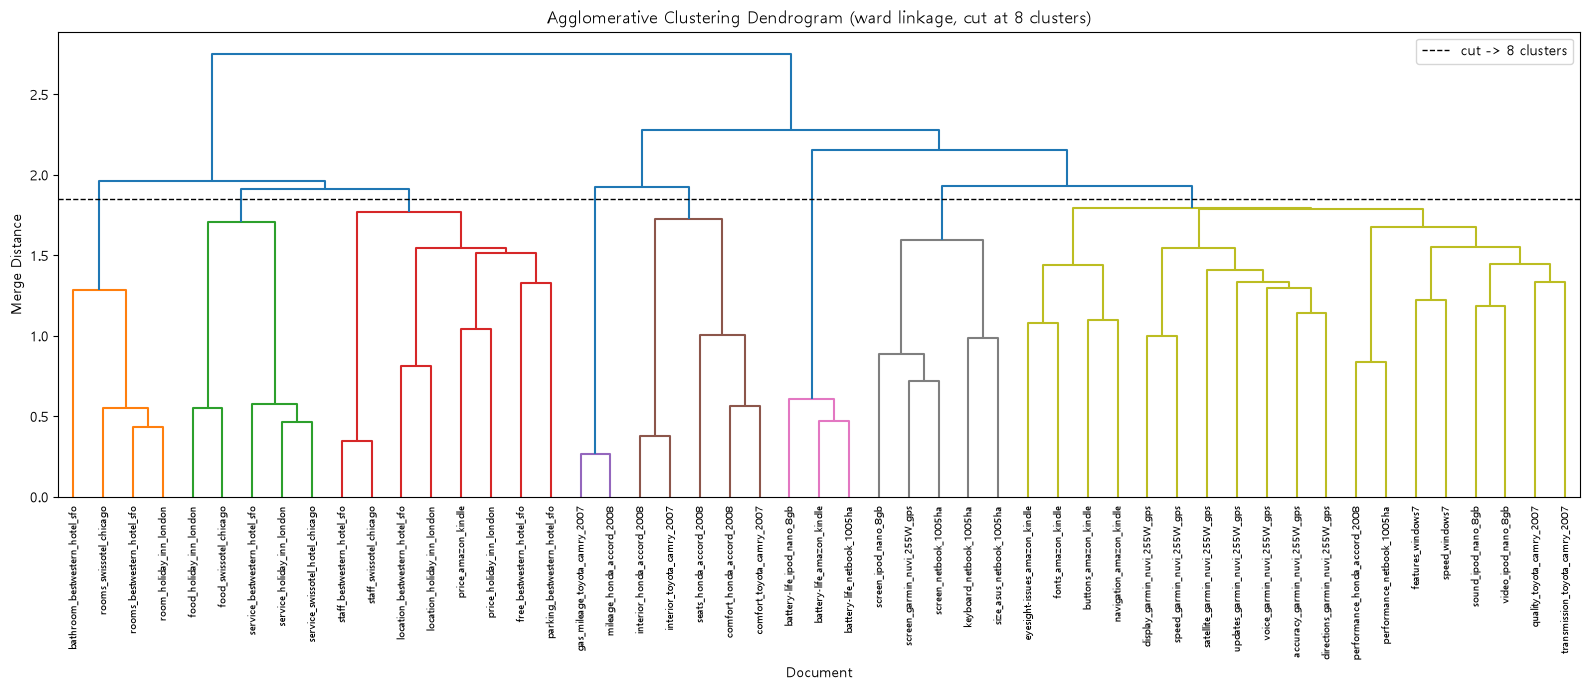

In [51]:
# Agglomerative 병합 과정 전체를 덴드로그램으로 시각화 (ward linkage, 최종 채택 모델과 동일한 방식)
from scipy.cluster.hierarchy import dendrogram, linkage  # 덴드로그램 함수 임포트

Z = linkage(X_dense, method='ward')  # 51개 문서 -> 1개로 합쳐지는 전체 병합 과정을 기록

n = X_dense.shape[0]  # 전체 문서 수 (51)
merge_idx = n - best_k  # best_k개가 남는 시점까지의 병합 횟수
cut_height = (Z[merge_idx - 1, 2] + Z[merge_idx, 2]) / 2  # 그 다음 병합과의 중간 높이에서 자름

plt.figure(figsize=(16, 7))  # 그래프 크기
dendrogram(Z, labels=document_df['filename'].values, leaf_rotation=90, leaf_font_size=7,
           color_threshold=cut_height)  # cut_height 아래는 클러스터별로 다른 색
plt.axhline(y=cut_height, color='black', linestyle='--', linewidth=1, label=f'cut -> {best_k} clusters')  # 자르는 위치 표시
plt.title(f'Agglomerative Clustering Dendrogram (ward linkage, cut at {best_k} clusters)')  # 제목
plt.xlabel('Document')  # x축 라벨
plt.ylabel('Merge Distance')  # y축 라벨
plt.legend()  # 범례
plt.tight_layout()  # 레이아웃 정리
plt.show()  # 출력

### 10 정리 — 실제로 효과가 있었나

**10-1. linkage/metric 튜닝 결과**: 4x3(일부 조합 제외) 스캔 결과 **기존에 쓰던 기본값(ward+euclidean)이 그대로 최고점(0.1518)** 이었습니다. 다른 조합들은 전부 이보다 낮게 나와서, cosine 거리가 이론적으로 더 잘 맞을 거라는 예상과 달리 이 데이터에서는 원래 설정이 이미 최적이었다는 걸 확인했습니다. 즉 **튜닝은 실패가 아니라 검증** — "이미 최선의 설정을 쓰고 있었다"는 걸 데이터로 증명한 셈입니다.

**10-2. 도메인 불용어 제거 결과**: `thing`, `use`, `easy`, `problem` 등 30개 범용 단어를 제거하니 어휘 수가 4,462개 → 4,225개로 줄었고, Agglomerative 실루엣 스코어는 **0.1518 → 0.1531 (+0.0013)** 로 아주 미세하게 개선됐습니다. best_k는 8로 그대로 유지됐습니다.

**결론**: 두 실험 모두 극적인 개선은 아니었지만, ①지금 쓰는 설정이 이미 합리적으로 최적화되어 있다는 걸 재확인했고 ②도메인 불용어 제거는 방향은 맞지만 이 데이터(51개, 이미 lemmatization까지 적용됨)에서는 개선 여지가 크지 않았습니다. 51개라는 적은 문서 수 자체가 스코어를 크게 흔들 수 있는 한계로 보입니다.